# Fig. 3 第一阶段案例图

这个 notebook 生成第一阶段 old/new tokenizer 的地理配准案例图。

建议用途：
- 放在主文 Figure 3
- 用案例解释“new 为什么更好、好在哪里”
- 为了主文可读性，默认只绘制改进最明显的 2 个代表性 case
- 全部 case 的定量结果仍然会保存在导出的 CSV 里


In [1]:
import sys
from pathlib import Path


def find_gptcast_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'gptcast').is_dir():
            return p
        if (p / 'GPTCast' / 'gptcast').is_dir():
            return (p / 'GPTCast').resolve()
        p = p.parent
    return start.resolve()


ROOT = find_gptcast_root(Path.cwd())
NOTEBOOK_DIR = ROOT / 'notebooks' / 'rzsm'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from soilcast_stage1_paper_figures import CaseSpec, SearchConfig, default_cases, make_case_study_figure, set_seed


/home/ang/miniconda3/envs/gptcast/lib/python3.12/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


/home/ang/miniconda3/envs/gptcast/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/ang/miniconda3/envs/gptcast/lib/

Working with z of shape torch.Size([7, 8, 17, 17]) = 16184 dimensions.
Working with z of shape torch.Size([7, 8, 17, 17]) = 16184 dimensions.
已生成案例图: /home/ang/GPTCast/outputs/stage1_tokenizer_paper/fig3_stage1_case_studies.png


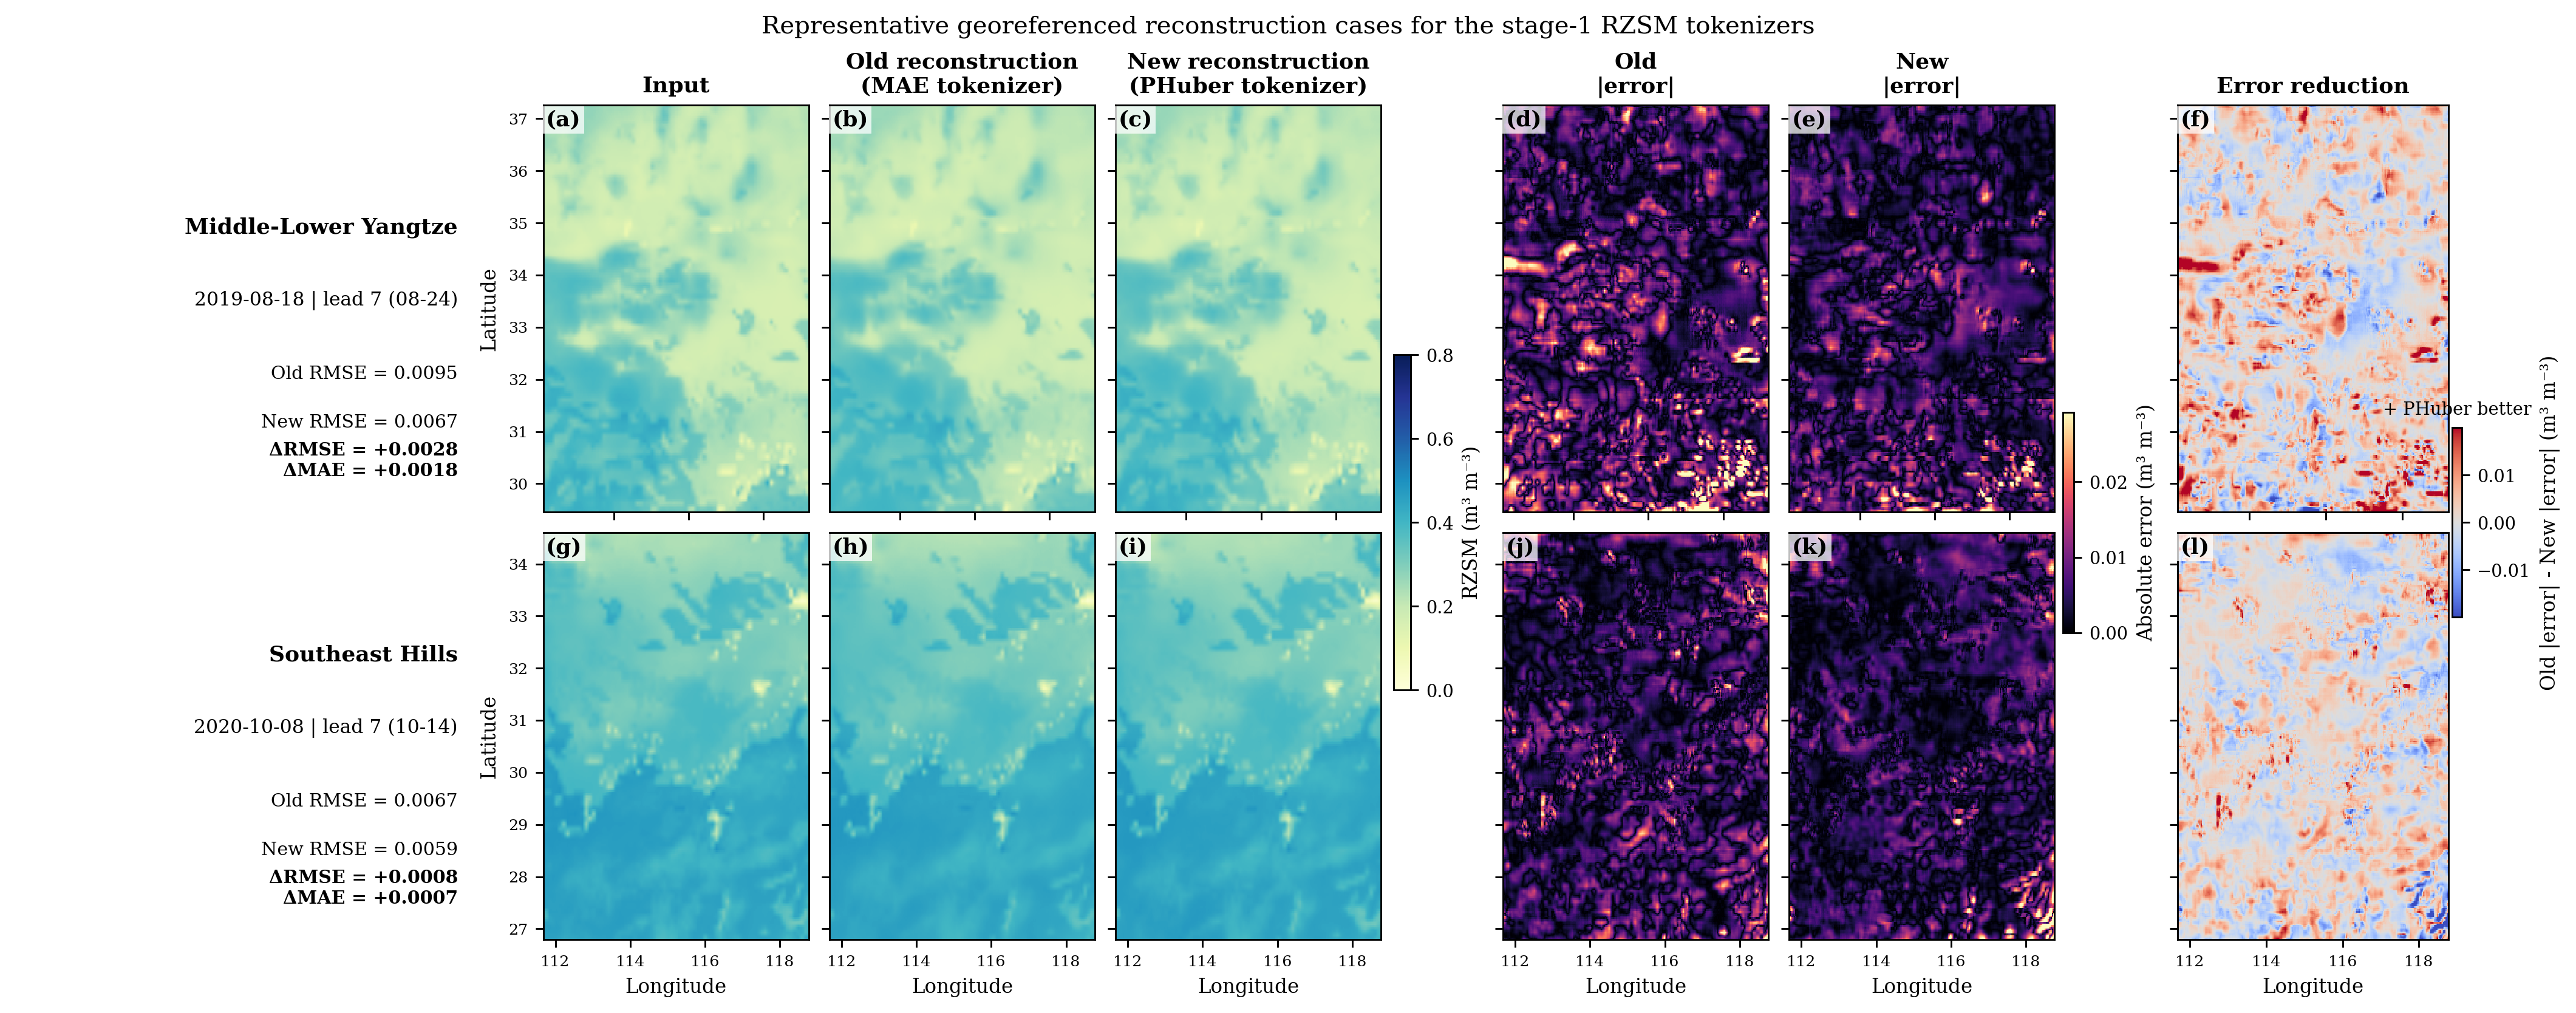


建议英文 caption：
Figure 3. Representative georeferenced stage-1 reconstruction cases for the RZSM tokenizers. The two cases shown here correspond to benchmark crops with the largest RMSE improvements in favor of the PHuber tokenizer. For each case, the figure compares the input field, reconstructions from the MAE-based and PHuber-based tokenizers, their absolute errors, and the error-improvement map. Warm colors in the improvement panels indicate locations where the PHuber tokenizer reduces reconstruction error relative to the MAE tokenizer.

建议中文 caption：
图3. 第一阶段 RZSM tokenizer 的代表性地理配准重建案例图。图中展示的是在 benchmark crop 中相对于 MAE tokenizer 具有最大 RMSE 改善的两个代表案例。对于每个案例，图中对比了输入场、MAE tokenizer 重建、PHuber tokenizer 重建、对应的绝对误差，以及误差改进图。改进图中的暖色表示 PHuber tokenizer 相比 MAE tokenizer 降低了该位置的重建误差。


In [2]:
set_seed(42)
ckpt_old = ROOT / 'models' / 'vae_mae_rzsm.ckpt'
ckpt_new = ROOT / 'models' / 'vae_phuber_rzsm.ckpt'
base_dir = ROOT / 'data' / '0.1' / '1' / 'land_surface'
output_dir = ROOT / 'outputs' / 'stage1_tokenizer_paper'
cases = default_cases()
search_cfg = SearchConfig(search_attempts=128, jitter_px=110, selection_mode='dynamic_near_roi')
case_df, case_summary = make_case_study_figure(
    ckpt_old=ckpt_old,
    ckpt_new=ckpt_new,
    cases=cases,
    base_dir=base_dir,
    output_dir=output_dir,
    search=search_cfg,
    save_stem='fig3_stage1_case_studies',
)
print('已生成案例图:', case_summary['png_path'])
from IPython.display import Image, display
display(Image(filename=case_summary['png_path']))

print('\n建议英文 caption：')
print(case_summary['caption_en'])
print('\n建议中文 caption：')
print(case_summary['caption_zh'])
